# Code to simulate a synthetic GRN and infer the network using TwINFER


## Details about the simulation

### Set this for both running the simulation and before inferring using TwINFER


In [1]:
import sys
from pathlib import Path
path_to_code_repo = Path("/home/mzo5929/Keerthana/grnInference/code/grnInferenceRepo")
sys.path.append(str(path_to_code_repo))


In [8]:
path_to_data = "/home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/"

base_config = {
    'n_cells': 6000, #Number of cells before division (number of twin pairs)
    'simulation_time_before_division': 1000, #The time used to run the initial cells before division. User must set this time to ensure the population reaches steady state [hours]
    'twin_simulation_time_after_division': 48, #The time twin cells are simulated after division and measurements are stored in the output[hours]
    'twin_measurement_resolution': 1, #The time between each measurement of twin cells [hours]. For example, if twin_sampling_duration is 12 and twin_measurement_resolution is 1, the final dataframe will contain hourly measurements for 12 hours (0 is birth).
    "path_to_connectivity_matrix": f"{path_to_data}/figure_2_simulation_details/interaction_matrix_A_to_B.txt", #path to the connectivity matrix specifying the GRN to simulate
    "param_csv": f"{path_to_data}/figure_2_simulation_details/median_param.csv", #Path to the parameters for all genes and interaction terms
    "rows_to_use": [[0,1]], #Rows in the parameter's csv file for each gene - the length should be equal to number of genes in the system
    "output_folder": f"{path_to_data}/figure_2_simulations_8000_cells/A_to_B/", #Path to folder to store simulation 
    "log_file": f"{path_to_data}/figure_2_simulation_details/fig_2_median_parameter_simulations_8000_cells.jsonl", #Path to the log file
    "type": "A_to_B",  # Name of the network used -- will be in the filename
    "number_of_parallel_parameters": 1, #Number of parameters to be run in parallel
    "number_of_cores_per_parameter": 8, #Number of cores to be used per parameter (number_of_parallel_parameters * number_of_cores_per_parameter = number of cores in your computer)
}

## Functions and packages used in this notebook - run this everytime notebook is restarted


### For the simulation


In [10]:
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import os
import sys
import numpy as np
from numba import set_num_threads, get_num_threads
set_num_threads(base_config['number_of_cores_per_parameter'])
print("Threads Numba will use:", get_num_threads())

import importlib
from simulation_scripts.gillespie_simulation import gillespie_script

importlib.reload(gillespie_script)


from simulation_scripts.gillespie_simulation.gillespie_script import process_param_set



Threads Numba will use: 8


### For inferring with TwINFER


In [11]:
# Calculation functions
import importlib
from simulation_scripts.gillespie_simulation import correlation_analysis_functions
from simulation_scripts.gillespie_simulation import correlation_analysis_helpers

importlib.reload(correlation_analysis_functions)
importlib.reload(correlation_analysis_helpers)

from simulation_scripts.gillespie_simulation.correlation_analysis_functions import (
    calculate_pairwise_gene_gene_correlation_matrix,
    check_system_in_steady_state,
    check_gene_gene_correlation_threshold,
    calculate_twin_random_pair_correlations,
    differentiate_single_state_reg_and_multiple_states,
    identify_reg_if_multiple_states,
    get_directions_from_simulation
)

# Helper functions
from simulation_scripts.gillespie_simulation.correlation_analysis_helpers import (
    extract_param_index,
    read_input_matrix,
    get_param_data, 
    plot_matrix_as_heatmap,
    print_summary,
    plot_network
)

import pandas as pd
import matplotlib.pyplot as plt

In [16]:
def infer_using_twinfer(path_to_simulation_file, base_config, t1, t2, 
                        check_for_steady_state=True, 
                        plot_correlation_matrices_as_heatmap=True, have_any_output = True):
    """
    Perform twin-based inference of gene regulatory interactions from simulation data.

    This function analyzes simulation results to identify gene-gene regulatory relationships,
    distinguish between single- and multi-state regulation, and infer directionality using
    time-shifted correlations between twin cells.

    Parameters
    ----------
    path_to_simulation_file : str
        Path to the CSV file containing simulation output (one clone per row per timepoint).
    
    base_config : dict
        Dictionary containing simulation metadata and parameters:
            - "n_cells": expected number of twin clones
            - "twin_simulation_time_after_division": total duration after division (hours)
            - "twin_measurement_resolution": sampling resolution (hours)
            - "path_to_connectivity_matrix": file path to interaction matrix
            - "param_csv": file path to parameter CSV
            - "rows_to_use": list of row index sets used in this simulation

    t1 : int
        Timepoint (in hours) for early gene expression correlation.

    t2 : int
        Timepoint (in hours) for late-stage twin/random cell analysis.

    check_for_steady_state : bool, default=True
        If True, checks that simulations have reached steady state by t1.

    plot_correlation_matrices_as_heatmap : bool, default=True
        If True, visualizes intermediate correlation matrices using heatmaps.

    Returns
    -------
    dict
        Dictionary of inference results:
            - "direction_matrix": directional correlation matrix (t1 → t2)
            - "direction_raw_matrix": raw correlation difference matrix (no threshold)
            - "pairwise_gene_gene_correlation_matrix": gene-gene correlations at t1
            - "twin_pair_correlation_matrix_t2": twin correlation matrix at t2
            - "random_pair_correlation_matrix_t2": random correlation matrix at t2
            - "twin_pair_correlation_matrix_t1": twin correlation matrix at t1 (if used)
            - "random_pair_correlation_matrix_t1": random correlation matrix at t1 (if used)

    Notes
    -----
    - Regulation type is classified as either single-state or multi-state using twin vs random correlations.
    - Directionality is inferred only for single-state interactions.
    - Intermediate checks ensure simulation structure and parameter identity match the base_config.
    """


    # Load simulation data
    try:
        simulation = pd.read_csv(path_to_simulation_file)
    except Exception as e:
        raise RuntimeError(f"Error reading the simulation file: {e}")

    # Load connectivity matrix and parameter set
    path_to_connectivity_matrix = base_config["path_to_connectivity_matrix"]
    path_to_parameter_csv = base_config["param_csv"]
    param_df = pd.read_csv(path_to_parameter_csv, index_col=0)

    # --- Basic sanity checks ---
    # Assert number of clones in simulation file matches config
    n_clones_simulation = simulation['clone_id'].nunique()
    n_clones_base_config = base_config["n_cells"]
    assert n_clones_simulation == n_clones_base_config, \
        "Number of twin pairs in the simulation file does not match n_cells in base_config."

    # Assert time points match expected resolution
    time_points_simulations = simulation['time_step'].unique()
    time_points_base_config = np.arange(
        0, 
        base_config['twin_simulation_time_after_division'] + base_config['twin_measurement_resolution'], 
        base_config['twin_measurement_resolution']
    )

    assert set(time_points_simulations) == set(time_points_base_config), \
        "The sampling time points in the simulation file do not match those specified in base_config."

    # Assert parameter row identity matches
    param_index_from_file_name = extract_param_index(path_to_simulation_file)
    param_index_from_base_config = "_".join(map(str, base_config["rows_to_use"][0]))
    assert param_index_from_file_name == param_index_from_base_config, \
        "Simulation must match the details in base_config."

    # Load gene parameters and connectivity structure
    gene_params = get_param_data(param_df, param_index_from_file_name)
    n_genes, interaction_matrix = read_input_matrix(path_to_connectivity_matrix)
    gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]

    
    # --- Check for steady state at t1 (optional) ---
    if check_for_steady_state:
        is_system_in_steady_state = check_system_in_steady_state(simulation, gene_params, interaction_matrix, gene_list,
                                  relative_diff_threshold=0.05, relative_slope_threshold=0.01)
        if not is_system_in_steady_state:
            raise ValueError(
                "The system is not in steady state. "
                "You can override this by setting check_for_steady_state=False."
            )

    # Ensure the time points t1 and t2 exist in the simulation data
    unique_timepoints = simulation['time_step'].unique()

    if t1 not in unique_timepoints:
        raise ValueError(f"Time point t1={t1} not found in simulation['time_step'].")
    if t2 not in unique_timepoints:
        raise ValueError(f"Time point t2={t2} not found in simulation['time_step'].")

    # Subset the simulation at the desired timepoints

    # Shuffle all clone IDs
    clone_ids_shuffled = np.random.permutation(n_clones_simulation)

    # Split into 1:1:2 ratio
    n1 = n2 = n_clones_simulation // 4
    t1_clones = clone_ids_shuffled[:n1]
    t2_clones = clone_ids_shuffled[n1:n1 + n2]
    across_t_clones = clone_ids_shuffled[n1 + n2:]

    # Subset directly
    t1_twins = simulation[(simulation['clone_id'].isin(t1_clones)) & (simulation['time_step'] == t1)]
    t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]

    # Across_t: pick exactly one random twin per clone_id
    # One cell per clone at t1
    across_t_twin1 = (
        simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1)]
        .groupby('clone_id', group_keys=False)
        .sample(n=1, random_state=None)   # set an int for reproducibility
    )

    # One (different) cell from the SAME clones at t2
    candidates_t2 = simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2)]

    # Exclude the exact cell_ids picked at t1 (if cell_id persists across time)
    candidates_t2 = candidates_t2[~candidates_t2['cell_id'].isin(across_t_twin1['cell_id'])]

    # Now sample one per clone
    across_t_twin2 = (
        candidates_t2
        .groupby('clone_id', group_keys=False)
        .sample(n=1, random_state=None)
    )


    # Reset index for cleanliness
    t1_twins = t1_twins.reset_index(drop=True)
    t2_twins = t2_twins.reset_index(drop=True)
    across_t_twin1 = across_t_twin1.reset_index(drop=True)
    across_t_twin2 = across_t_twin2.reset_index(drop=True)

    all_t1_t2_measurements = pd.concat(
    [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
    ignore_index=True
    )

    
    # --- Step 1: Pairwise gene-gene correlations at t1 ---
    pairwise_gene_gene_correlation_matrix = calculate_pairwise_gene_gene_correlation_matrix(
        all_t1_t2_measurements, gene_list
    )

    no_regulation, potential_regulation = check_gene_gene_correlation_threshold(
        pairwise_gene_gene_correlation_matrix, gene_list, threshold = 0.0235
    )
    # print(no_regulation)
    if plot_correlation_matrices_as_heatmap:
        plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix, gene_list=gene_list, no_regulation=no_regulation, potential_regulation=potential_regulation,
            title=f"Gene-gene correlations at time {t1}h", add_gene_labels=True, add_time=False, gray_out_no_reg=False
        )

    # --- Step 2: Twin/random correlations at t2 ---
    twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
        all_t1_t2_measurements, t2_twins, gene_list
    )
    # print(twin_pair_correlation_matrix_t2)
    if plot_correlation_matrices_as_heatmap:
        plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t2, gene_list=gene_list, no_regulation=no_regulation, potential_regulation=potential_regulation,
            title=f"Twin pair correlations at time {t2}h", add_gene_labels=True, add_time=True, time=[t2], gray_out_no_reg=True
        )
        
        plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t2, gene_list=gene_list, no_regulation=no_regulation, potential_regulation=potential_regulation,
            title=f"Random pair correlations at time {t2}h", add_gene_labels=True, add_time=True, time=[t2], gray_out_no_reg=True
        )

    # --- Step 3: Classify regulation type: single-state vs multiple-states ---
    multiple_states_gene_pairs, single_state_regulation = differentiate_single_state_reg_and_multiple_states(
        potential_regulation, twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2, gene_list
    )
    twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1 = calculate_twin_random_pair_correlations(
                all_t1_t2_measurements, t1_twins, gene_list
            )
    if len(multiple_states_gene_pairs) > 0:
        
        multiple_states_no_reg, multiple_states_and_reg = identify_reg_if_multiple_states(
            twin_pair_correlation_matrix_t1,twin_pair_correlation_matrix_t2,random_pair_correlation_matrix_t1,
            random_pair_correlation_matrix_t2,multiple_states_gene_pairs,gene_list
            )
    else:
        multiple_states_no_reg, multiple_states_and_reg = [], []

    # --- Step 4: Print summary of results ---
    if have_any_output:
        print_summary(no_regulation, single_state_regulation, multiple_states_no_reg, multiple_states_and_reg)
    
    # --- Step 5: Infer directionality of single-state interactions ---

    direction_raw_matrix, direction_normalized_matrix, pre_threshold_direction_matrix = get_directions_from_simulation(across_t_twin1, across_t_twin2, gene_pairs=single_state_regulation, threshold=None)
    # print(pre_threshold_direction_matrix)

    if plot_correlation_matrices_as_heatmap:
        # Mark all (i, j) entries where direction could not be determined
        undirected_pairs = [
            (g1, g2)
            for g1 in direction_normalized_matrix.index
            for g2 in direction_normalized_matrix.columns
            if (g1, g2) not in single_state_regulation
        ]

        plot_matrix_as_heatmap(
            corr_matrix=direction_normalized_matrix,
            gene_list=list(direction_normalized_matrix.index),
            no_regulation=undirected_pairs,                   
            potential_regulation=single_state_regulation,     
            title=f"Directional correlations (from {t1}h to {t2}h)",
            add_gene_labels=True,
            add_time=True,
            time=[t1, t2],
            gray_out_no_reg=True
        )

    # --- Step 6: Visualize the inferred network ---
    if (len(single_state_regulation) > 0):
        if have_any_output:
            plot_network(direction_normalized_matrix, gene_list)

    return {
        "direction_matrix": direction_normalized_matrix, 
        "direction_raw_matrix": direction_raw_matrix, 
        "pairwise_gene_gene_correlation_matrix": pairwise_gene_gene_correlation_matrix,
        "twin_pair_correlation_matrix_t2": twin_pair_correlation_matrix_t2,
        "random_pair_correlation_matrix_t2": random_pair_correlation_matrix_t2,
        "twin_pair_correlation_matrix_t1": twin_pair_correlation_matrix_t1,
        "random_pair_correlation_matrix_t1": random_pair_correlation_matrix_t1
    }

## Simulate the gene expression in a population of cells

The code simulates gene expression based on a GRN (described by the interaction matrix) and expression of each gene is defined by parameters (each row in the parameter sheet) using the Gillespie algorithm.


In [ ]:
os.makedirs(base_config['output_folder'], exist_ok=True)
rows_to_use = base_config['rows_to_use']
labels = ["rows_" + "_".join(map(str, row)) for row in rows_to_use]
param_sets = list(zip(rows_to_use, labels))

# Run over specified number of jobs (workers)
results = Parallel(n_jobs=base_config['number_of_parallel_parameters'])(
    delayed(process_param_set)(rows, label, base_config)
    for rows, label in tqdm(param_sets, total=len(param_sets), desc="All iterations")
)

# Print results (matching the concurrent.futures style)
for (rows, label), res in zip(param_sets, results):
    print(f"Completed simulation for {label} (rows={rows}): {res}")

In [ ]:
import copy
from tqdm.auto import tqdm

for i in tqdm([20,99]):
    run_config = copy.deepcopy(base_config)
    run_config["type"] = f"{run_config['type']}_rep_{i}"

    os.makedirs(run_config['output_folder'], exist_ok=True)
    
    rows_to_use = run_config['rows_to_use']
    labels = ["rows_" + "_".join(map(str, row)) for row in rows_to_use]
    param_sets = list(zip(rows_to_use, labels))

    # Run the simulation for this replicate
    results = Parallel(n_jobs=run_config['number_of_parallel_parameters'])(
        delayed(process_param_set)(rows, label, run_config)
        for rows, label in param_sets
    )

    for (rows, label), res in zip(param_sets, results):
        print(f"[Rep {i}] Completed simulation for {label} (rows={rows}): {res}")

# Using TwINFER to infer network from the simulation

### Before starting, set the time-points used as t1 and t2. The default is 1 hour and 10 hours after division.

TwINFER uses three kinds of correlations used for distinguishing multiple-states and regulation.

- First, calculate gene-gene correlations $\rho$ for all pairs of genes at time t1. This will identify gene-pairs that are potentially interacting.
- Second, calculate twin pair correlation $\hat{\rho}_{\Delta}$ and random pair correlation. Comparing these two for all gene pairs will detect the existence of multiple states in the population vs just regulation.
- Finally, if there are multiple states in the population, compare twin pair correlation $\hat{\rho}_{\Delta}$ at time t1 and time t2. This will detect the existence of regulatory interaction.

Next, if there is regulation and single-state in the population, TwINFER can identify direction of regulatory interaction. This is done be comparing cross-correlations between twins at the two timepoints.

### Based on this algorithm, a network will be inferred and plotted.


### Input to TwINFER


In [6]:
t1 = 1 #time [hours] after division when t1 sample is collected
t2 = 10 #time [hours] after division when t2 sample is collected

#This should be the simulation matching the details in base_config
#path to the simulation output file - this will be printed at the end of the simulation
path_to_simulation_file = "/home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/figure_2_simulations_6000_cells/A_to_B/df_rows_0_1_05082025_160041_ncells_6000_A_to_B_rep_0.csv" 

### Run TwINFER for inference using the simulation, base_config, t1 and t2.


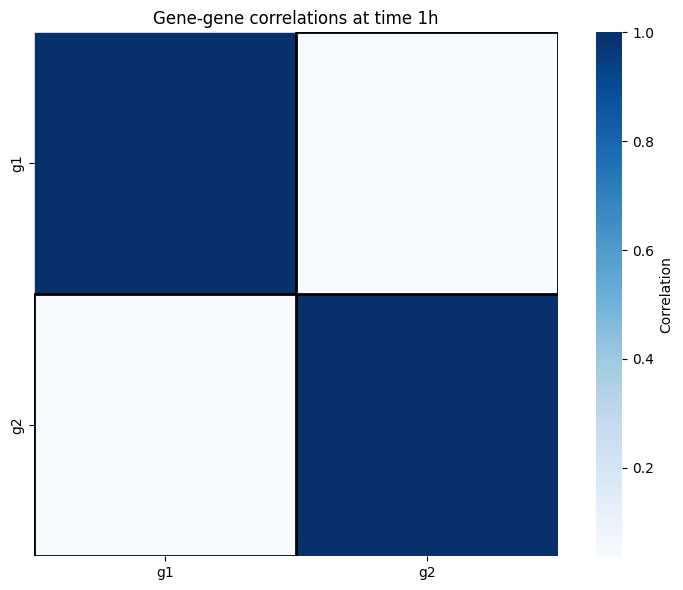

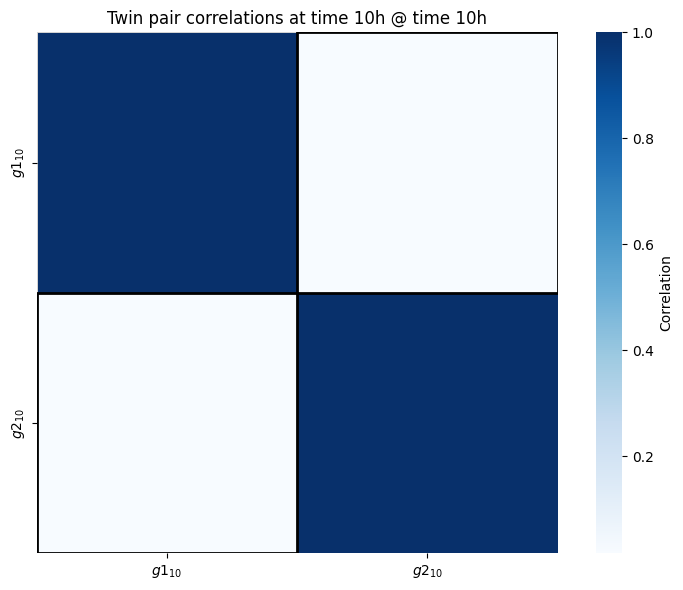

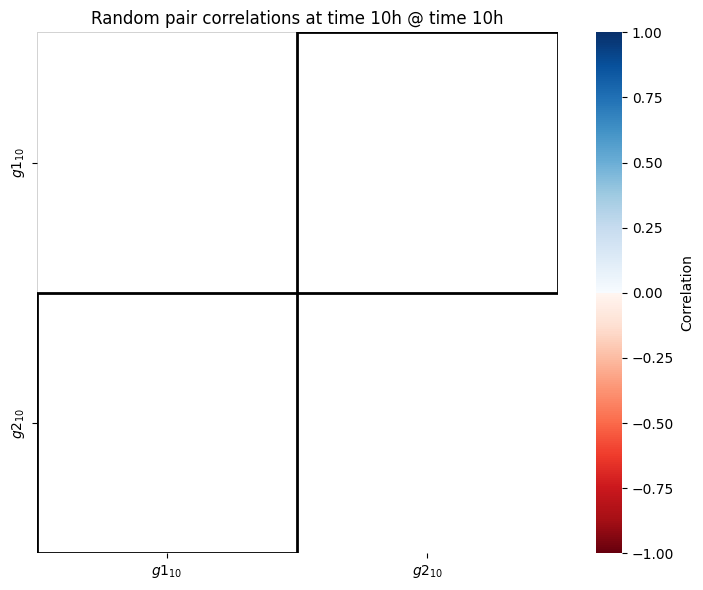


1. No Regulation
  (none)

2. Single-State Regulation
  gene_1 - gene_2
  gene_2 - gene_1

3. Multiple States (No Regulation)
  (none)

4. Multiple States with Regulation
  (none)


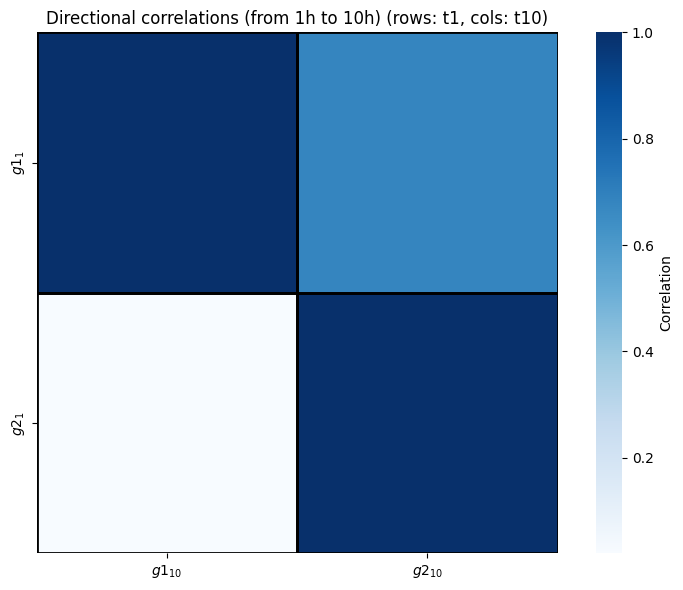

/projects/b1042/GoyalLab/Keerthana/grnInference/code/grnInferenceRepo/simulation_scripts/gillespie_simulation/correlation_analysis_helpers.py:554: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(min(y_vals) - 0.3 * y_range, max(y_vals) + 0.3 * y_range)


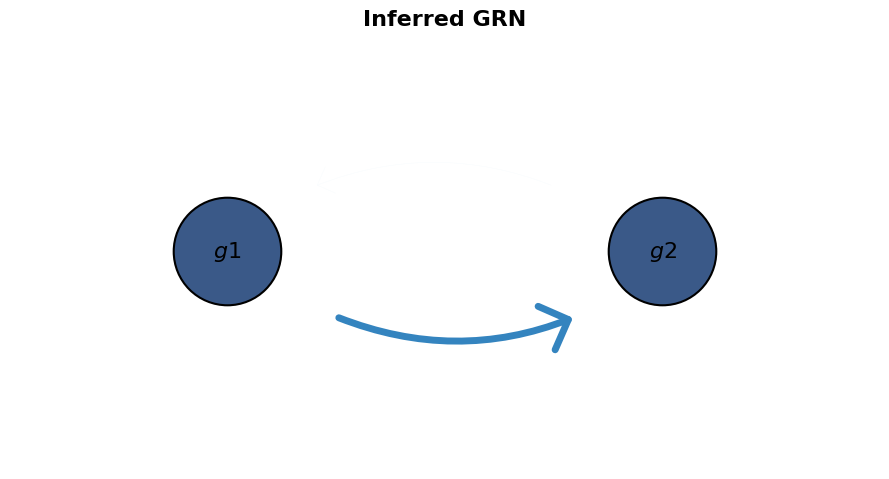

In [17]:
correlation_matrices = infer_using_twinfer(path_to_simulation_file, base_config, t1, t2, 
                        check_for_steady_state=True, 
                        plot_correlation_matrices_as_heatmap=True)

In [18]:
from itertools import product
from joblib import Parallel, delayed
from tqdm import tqdm
from tqdm_joblib import tqdm_joblib
import numpy as np

# Precompute t1-t2 pairs
t1_t2_pairs = [(t1, t2) for t1 in np.arange(1, 49, 1) for t2 in np.arange(t1, 49, 1)]

def run_inference_for_pair(t1, t2):
    
    correlation_matrices = infer_using_twinfer(
            path_to_simulation_file,
            base_config,
            t1,
            t2,
            check_for_steady_state=False,
            plot_correlation_matrices_as_heatmap=False,
            have_any_output=False  # must be supported in your function
    )
    try:
        pairwise_gene_gene_correlation_matrix = correlation_matrices['pairwise_gene_gene_correlation_matrix']
        raw_corr_matrix = correlation_matrices['direction_raw_matrix']
        norm_corr_matrix = correlation_matrices['direction_matrix']

        n_genes_all = pairwise_gene_gene_correlation_matrix.shape[0]
        n_genes_directional = raw_corr_matrix.shape[0]
        output = {"t1": t1, "t2": t2}

        # Add pairwise gene-gene correlations (symmetric)
        for i, j in product(range(n_genes_all), repeat=2):
            if i <= j:  # avoid duplicates like (1,0) and (0,1) for symmetric
                key = f"gene_gene_corr_{i}_{j}"
                output[key] = pairwise_gene_gene_correlation_matrix.iloc[i, j]

        # Add directional correlations (raw and normalized)
        for i, j in product(range(n_genes_directional), repeat=2):
            output[f"raw_corr_{i}_{j}"] = raw_corr_matrix.iloc[i, j]
            output[f"norm_corr_{i}_{j}"] = norm_corr_matrix.iloc[i, j]

        return output
        raise
    except Exception as e:
        raise
        output = {"t1": t1, "t2": t2, "error": str(e)}
        pairwise_gene_gene_correlation_matrix = correlation_matrices['pairwise_gene_gene_correlation_matrix']
        n_genes = pairwise_gene_gene_correlation_matrix.shape[0]
        for i, j in product(range(n_genes), repeat=2):
            if i <= j:  # avoid duplicates like (1,0) and (0,1) for symmetric
                key = f"gene_gene_corr_{i}_{j}"
                output[key] = pairwise_gene_gene_correlation_matrix.iloc[i, j]
        # In case of failure, still return t1/t2 and partial info if possible
        return output

# Parallel execution with progress bar
with tqdm_joblib(tqdm(desc="Running Twinfer inference", total=len(t1_t2_pairs))):
    results = Parallel(n_jobs=8)(delayed(run_inference_for_pair)(t1, t2) for t1, t2 in t1_t2_pairs)

Running Twinfer inference:   0%|          | 0/1176 [00:00<?, ?it/s]

  0%|          | 0/1176 [00:00<?, ?it/s]

In [19]:
def plot_directional_correlation_heatmap(df, value_col, title, cmap="coolwarm_r", figsize=(12, 8)):
    """
    Plots a directional correlation heatmap with symmetric color scaling around 0.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with columns ["t1", "t2", value_col]
    value_col : str
        Name of the column in df to plot as heatmap values (e.g., "corr_01")
    title : str
        Title of the plot
    cmap : str or Colormap
        Colormap to use for the heatmap
    figsize : tuple
        Figure size
    """

    # Pivot to matrix form
    heatmap_data = df.pivot(index="t1", columns="t2", values=value_col)

    # Calculate symmetric color scale
    abs_max = min(10, np.nanmax(np.abs(heatmap_data.values)))
    vmin, vmax = -abs_max, abs_max

    # Plot
    fig, ax = plt.subplots(figsize=figsize)

    img = ax.imshow(heatmap_data.values, cmap=cmap, aspect='equal', vmin=vmin, vmax=vmax)

    # Set ticks and labels
    ax.set_xticks(np.arange(heatmap_data.shape[1]))
    ax.set_xticklabels(heatmap_data.columns)
    ax.set_yticks(np.arange(heatmap_data.shape[0]))
    ax.set_yticklabels(heatmap_data.index)

    # Colorbar
    cbar = fig.colorbar(img, ax=ax)
    cbar.set_label(f"{title}")

    # Axis labels and title
    ax.set_title(title)
    ax.set_xlabel("t2")
    ax.set_ylabel("t1")

    plt.tight_layout()
    plt.show()

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_directional_correlation_box_with_points(df, value_col, title,
                                                 figsize=(11, 6),
                                                 cap_abs_at=10,
                                                 point_alpha=0.65,
                                                 jitter=0.12,
                                                 marker_size=30):
    """
    Boxplot per t1 overlaid with jittered points for each t2.

    Parameters
    ----------
    df : pd.DataFrame with columns ["t1", "t2", value_col]
    value_col : str   # e.g., "corr_01"
    title : str
    figsize : tuple
    cap_abs_at : float  # y-scale cap similar to your heatmap (+/- this)
    point_alpha : float
    jitter : float      # horizontal jitter for points
    marker_size : int
    """
    # Clean & pivot
    d = df[["t1", "t2", value_col]].copy()
    d = d.dropna(subset=[value_col])
    # Stable sort by t1 then t2 so x-ordering is consistent
    d = d.sort_values(["t1", "t2"])

    # Build grouped data for boxplot (list of arrays in t1 order)
    t1_levels = pd.Index(sorted(d["t1"].unique()))
    grouped = [d.loc[d["t1"] == t1, value_col].to_numpy() for t1 in t1_levels]

    # y-limit symmetric around 0 (like your heatmap)
    abs_max = float(np.nanmax(np.abs(d[value_col]))) if len(d) else 1.0
    abs_max = min(cap_abs_at, abs_max)
    vmin, vmax = -abs_max, abs_max

    # Plot
    fig, ax = plt.subplots(figsize=figsize)

    # Boxplot
    bp = ax.boxplot(grouped, positions=np.arange(1, len(t1_levels) + 1),
                    widths=0.6, manage_ticks=False, patch_artist=False)

    # Overlay jittered points: scatter per row, positioned by t1 index + jitter
    # Map each t1 to its x location (1..N)
    t1_to_x = {t1: i+1 for i, t1 in enumerate(t1_levels)}

    # For reproducible jitter spread without changing global RNG
    rng = np.random.default_rng(42)
    xs = d["t1"].map(t1_to_x).to_numpy(dtype=float)
    xs = xs + rng.uniform(-jitter, jitter, size=xs.shape)

    ax.scatter(xs, d[value_col].to_numpy(),
               s=marker_size, alpha=point_alpha, linewidths=0)

    # Zero line, labels, ticks
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_xlim(0.5, len(t1_levels) + 0.5)
    ax.set_ylim(vmin, vmax)
    ax.set_xticks(np.arange(1, len(t1_levels) + 1))
    ax.set_xticklabels(t1_levels)
    ax.set_xlabel("t1")
    ax.set_ylabel(value_col)
    ax.set_title(title)

    plt.tight_layout()
    plt.show()


In [21]:
df = pd.DataFrame(results)
df.columns

Index(['t1', 't2', 'gene_gene_corr_0_0', 'gene_gene_corr_0_1',
       'gene_gene_corr_1_1', 'raw_corr_0_0', 'norm_corr_0_0', 'raw_corr_0_1',
       'norm_corr_0_1', 'raw_corr_1_0', 'norm_corr_1_0', 'raw_corr_1_1',
       'norm_corr_1_1'],
      dtype='object')

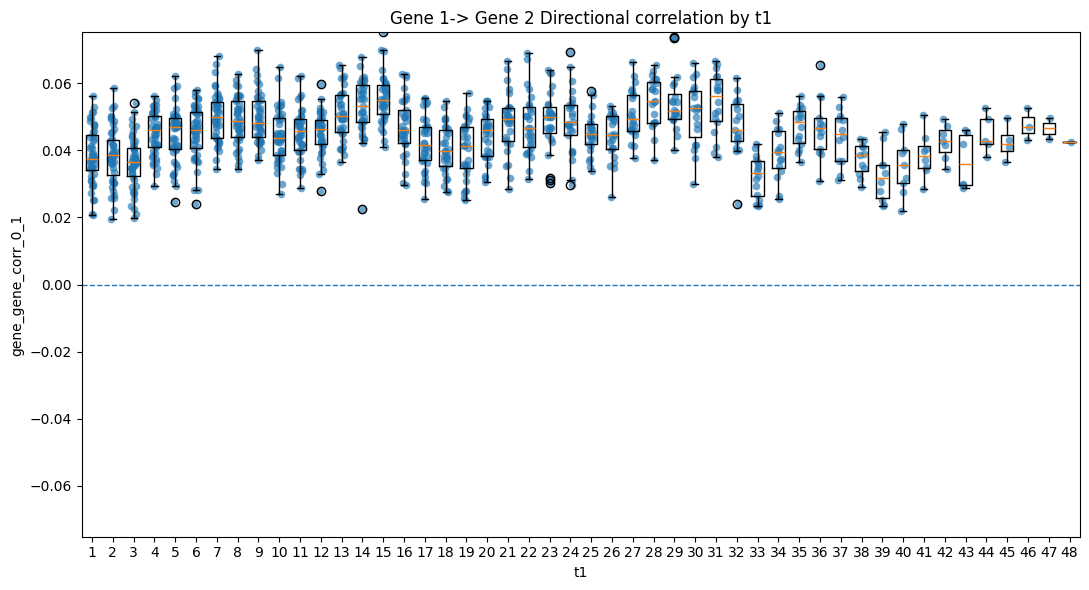

In [22]:


plot_directional_correlation_box_with_points(df, "gene_gene_corr_0_1",
                                             title="Gene 1-> Gene 2 Directional correlation by t1")

# plot_directional_correlation_box_with_points(df, "raw_corr_1_0",
#                                              title="Gene 1-> Gene 2 Directional correlation by t1")



## Generating two-state populations from the simulation data

To create a two (or multi) state population, read the simulation files for different populations and merge them.
